# TF-IDF + logistic regression baseline on OHSUMED

Non-LLM baseline: classify directly using a TF-IDF representation of the text.

### Prerequisites:

 - We will use [pandas](https://pandas.pydata.org/docs/) for data processing
 - We will use [scikit-learn](https://scikit-learn.org/stable/api/index.html) for the TF-IDF vectorizer and the logistic regression classifier

Furthermore, we will perform our experiments on the [OHSUMED dataset](https://huggingface.co/datasets/joao-luz/ohsumed-single).

In [1]:
%%capture
# install dependencies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers sentence-transformers accelerate tqdm datasets

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("joao-luz/ohsumed-single", split="train")
test_data = load_dataset("joao-luz/ohsumed-single", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 3357 examples
Test set size: 4043 examples


In [3]:
# convert datasets to dataframes, mapping the integer label to its disease category name:
label_names = train_data.features['label'].names
index2label = {i: name for i, name in enumerate(label_names)}

train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

train_df['label_name'] = train_df['label'].map(index2label)
test_df['label_name'] = test_df['label'].map(index2label)

# filter out empty texts:
train_df = train_df[train_df['text'].str.strip().astype(bool)]
test_df = test_df[test_df['text'].str.strip().astype(bool)]

train_df.sample()

,text,label,label_name
373,Neoadjuvant Cis-DDP in esophageal cancers: an ...,3,Neoplasms


In [4]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 2000 examples
Test subset size: 1000 examples


In [5]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label_name'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label_name'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  23


### Results Handling Helper

In [6]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [7]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file,
    including summary statistics.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Logistic Regression Classifier using TFIDF-Vectorizer

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

tfidf_lr = make_pipeline(
    TfidfVectorizer(),
    LogisticRegression(max_iter=1000)
)

tfidf_lr.fit(X_train, y_train)

predictions = tfidf_lr.predict(X_test)

Classification Report:
                                                      precision    recall  f1-score   support

                      Otorhinolaryngologic Diseases       0.00      0.00      0.00         7
                         Respiratory Tract Diseases       0.83      0.16      0.26        32
                Neonatal Diseases and Abnormalities       0.00      0.00      0.00        17
                            Stomatognathic Diseases       0.00      0.00      0.00         8
                       Hemic and Lymphatic Diseases       0.00      0.00      0.00        20
                                     Virus Diseases       0.00      0.00      0.00        12
Female Genital Diseases and Pregnancy Complications       0.67      0.08      0.14        26
                            Nervous System Diseases       0.62      0.27      0.38        85
                 Urologic and Male Genital Diseases       1.00      0.15      0.26        46
                                          Neo

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5]),
 [Text(0, 0.5, 'Otorhinolaryngologic Diseases'),
  Text(0, 1.5, 'Respiratory Tract Diseases'),
  Text(0, 2.5, 'Neonatal Diseases and Abnormalities'),
  Text(0, 3.5, 'Stomatognathic Diseases'),
  Text(0, 4.5, 'Hemic and Lymphatic Diseases'),
  Text(0, 5.5, 'Virus Diseases'),
  Text(0, 6.5, 'Female Genital Diseases and Pregnancy Complications'),
  Text(0, 7.5, 'Nervous System Diseases'),
  Text(0, 8.5, 'Urologic and Male Genital Diseases'),
  Text(0, 9.5, 'Neoplasms'),
  Text(0, 10.5, 'Eye Diseases'),
  Text(0, 11.5, 'Digestive System Diseases'),
  Text(0, 12.5, 'Endocrine Diseases'),
  Text(0, 13.5, 'Immunologic Diseases'),
  Text(0, 14.5, 'Pathological Conditions, Signs and Symptoms'),
  Text(0, 15.5, 'Cardiovascular Diseases'),
  Text(0, 16.5, 'Disorders of Environmental Origin'),
  Text(0, 17.5, 'Animal Diseases'),
  Text(

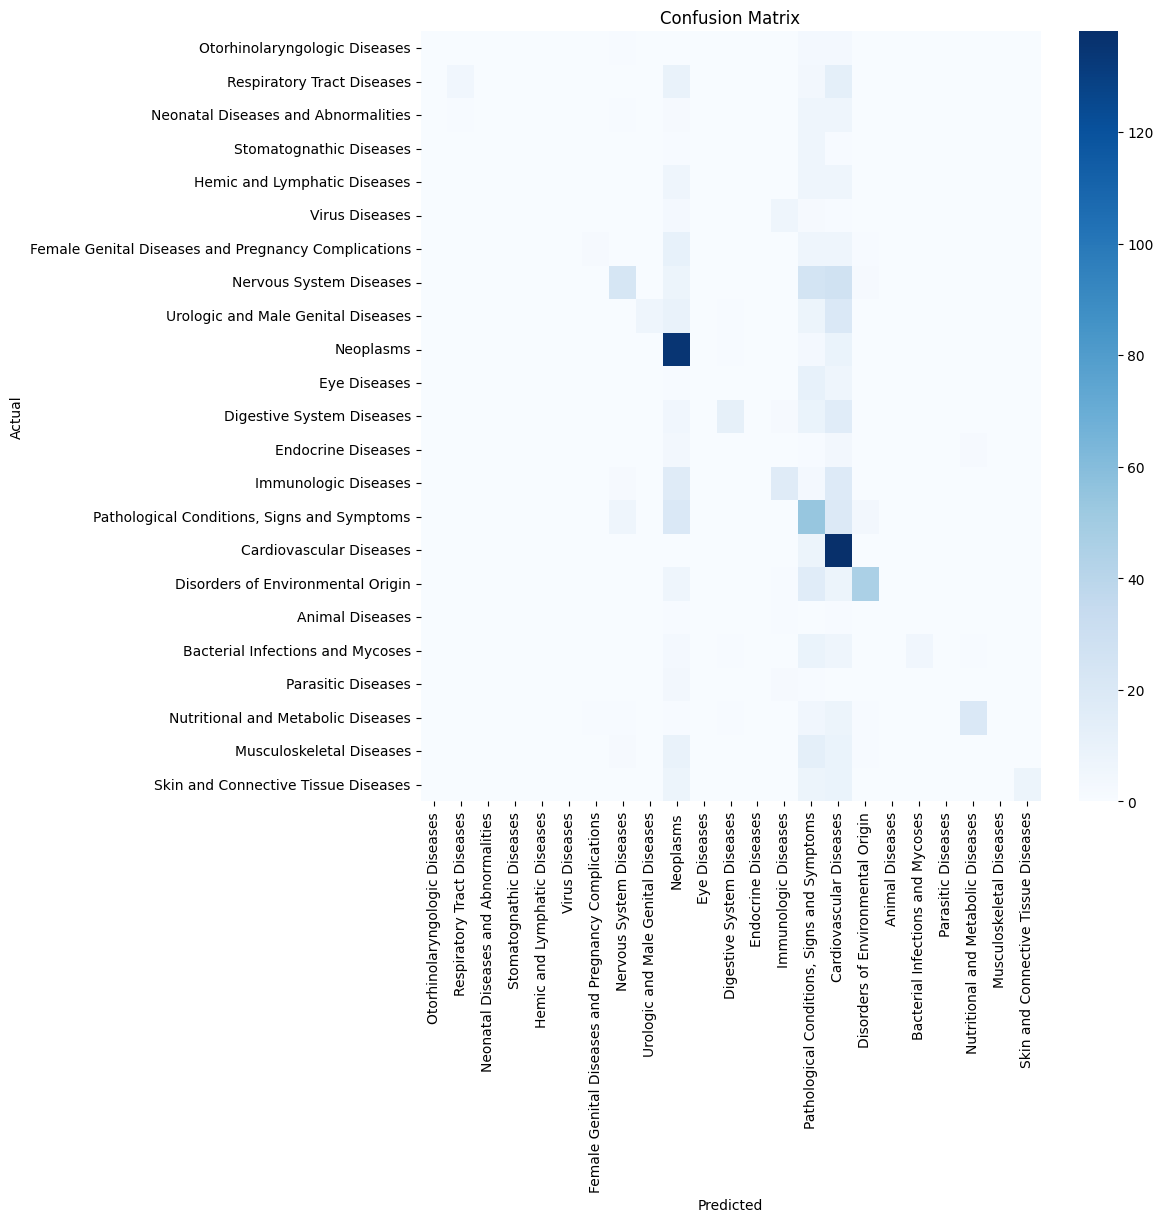

In [9]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=list(classes), yticklabels=list(classes))
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.xticks(rotation=90); plt.yticks(rotation=0)

In [10]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/ohsumed/results/predictions/ohsumed-tfidf-lr-2.0k-samples.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/ohsumed/results/predictions/ohsumed-tfidf-lr-2.0k-samples.json'
